In [ ]:
install.packages('caret')
install.packages('ROCR')
install.packages("MLmetrics")
install.packages("randomForest")
install.packages('gbm')
install.packages("h2o")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bitops’, ‘gtools’, ‘caTools’, ‘gplots’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘RCurl’




In [ ]:
library(caret)
library(ROCR)
library(ggplot2)
library(readxl)
library(MLmetrics)
library(randomForest)
library(gbm)
library(h2o)
library(tidyverse)
library(dplyr)

Loading required package: ggplot2

Loading required package: lattice


Attaching package: ‘MLmetrics’


The following objects are masked from ‘package:caret’:

    MAE, RMSE


The following object is masked from ‘package:base’:

    Recall


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


Loaded gbm 2.2.2

This version of gbm is no longer under development. Consider transitioning to gbm3, https://github.com/gbm-developers/gbm3


----------------------------------------------------------------------

Your next step is to start H2O:
    > h2o.init()

For H2O package documentation, ask for help:
    > ??h2o

After starting H2O, you can use the Web UI at http://localhost:54321
For more information visit https://docs.h2o.ai

----------------------------------------------------------------------



Attaching package: ‘h2o’


The following objects are masked fr

# Data Preparation

In [ ]:
telco<-read_excel('traintelco.xlsx')
telco<-telco[,-1]
str(telco)

tibble [8,243 × 10] (S3: tbl_df/tbl/data.frame)
 $ Fecha de nacimiento  : POSIXct[1:8243], format: "1990-05-01 00:05:22" "1980-06-30 19:08:57" ...
 $ tipo cliente         : num [1:8243] 2 2 2 2 1 2 2 2 1 1 ...
 $ Factura online       : num [1:8243] 1 0 0 1 1 1 1 1 1 0 ...
 $ Antigüedad Equipo    : num [1:8243] 9 41 38 11 6 21 5 7 6 37 ...
 $ Plan de datos        : num [1:8243] 0 1 1 1 0 1 0 0 1 1 ...
 $ facturación          : num [1:8243] 44588 341480 230662 205336 429525 ...
 $ mora                 : num [1:8243] 34 3 20 9 0 0 30 33 2 60 ...
 $ Fecha inicio contrato: POSIXct[1:8243], format: "2017-12-22 10:09:47" "2017-07-28 02:54:52" ...
 $ minutos              : num [1:8243] 644 663 1039 535 1869 ...
 $ resultado            : num [1:8243] 0 0 1 0 0 0 0 0 0 0 ...


In [ ]:
#Conversión del formato de fechas
telco$`Fecha de nacimiento` <- as.POSIXct(telco$`Fecha de nacimiento`, format="%Y-%m-%d %H:%M:%S")
telco$años_cliente <- 2024 - as.numeric(format(telco$`Fecha de nacimiento`, "%Y"))
telco$`Fecha inicio contrato` <- as.POSIXct(telco$`Fecha inicio contrato`, format="%Y-%m-%d %H:%M:%S")
telco$tiempo_contrato <- 2024 - as.numeric(format(telco$`Fecha inicio contrato`, "%Y"))
telco<-telco[,-c(1,8)]

In [ ]:
telco$`tipo cliente`<-as.factor(telco$`tipo cliente`)
telco$`tipo cliente`<-factor(telco$`tipo cliente`, levels = c(1, 2, 3))
telco$`Factura online` <- factor(telco$`Factura online`, levels = c(0, 1))
telco$`Plan de datos` <- factor(telco$`Plan de datos`, levels = c(0, 1))

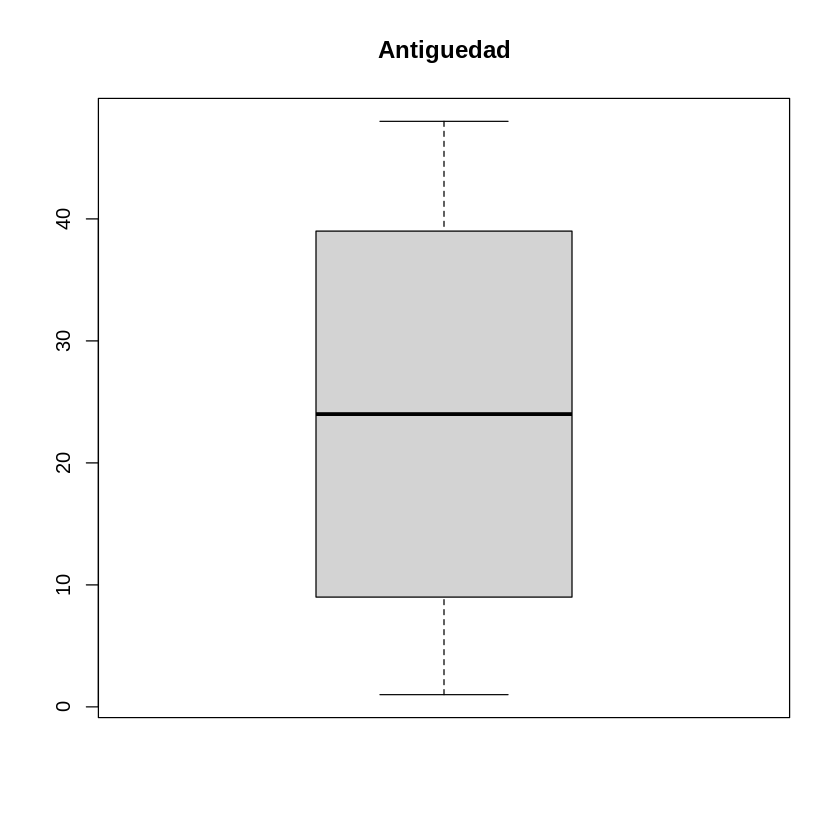

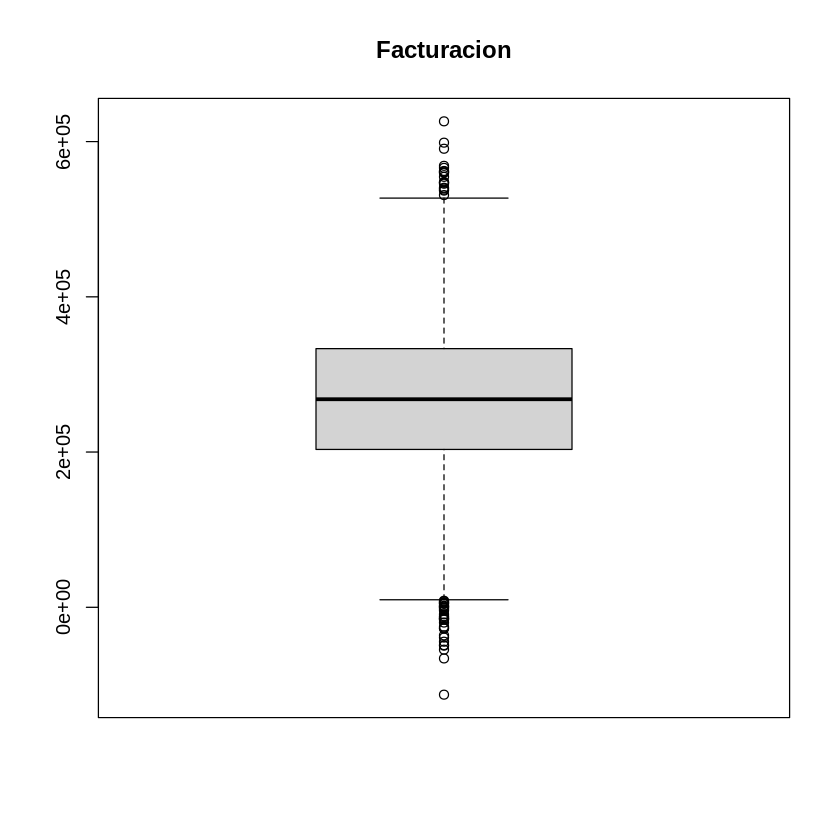

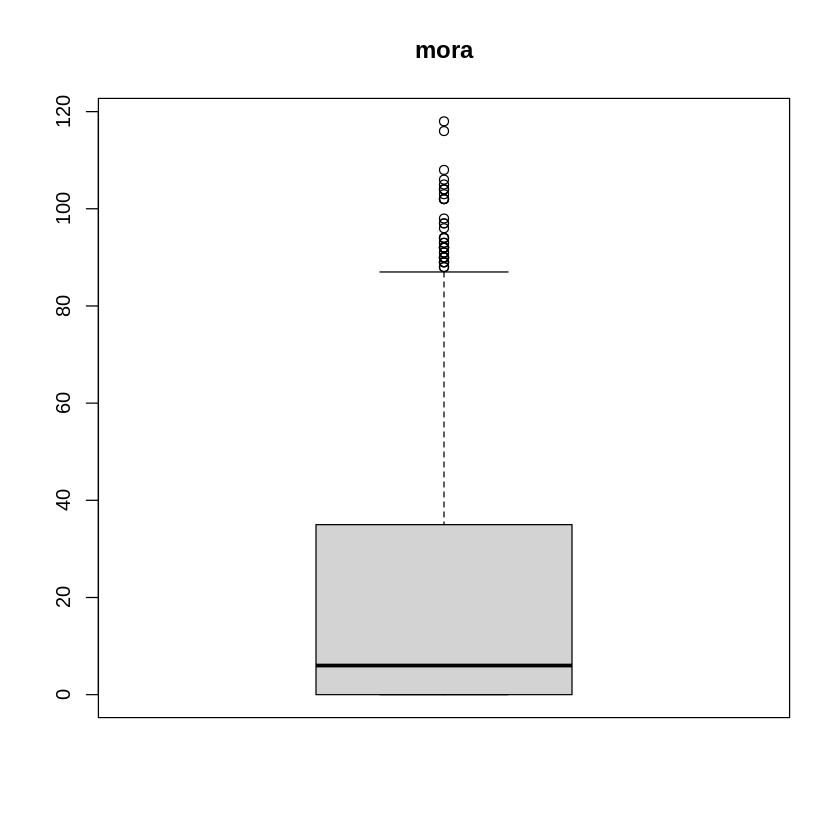

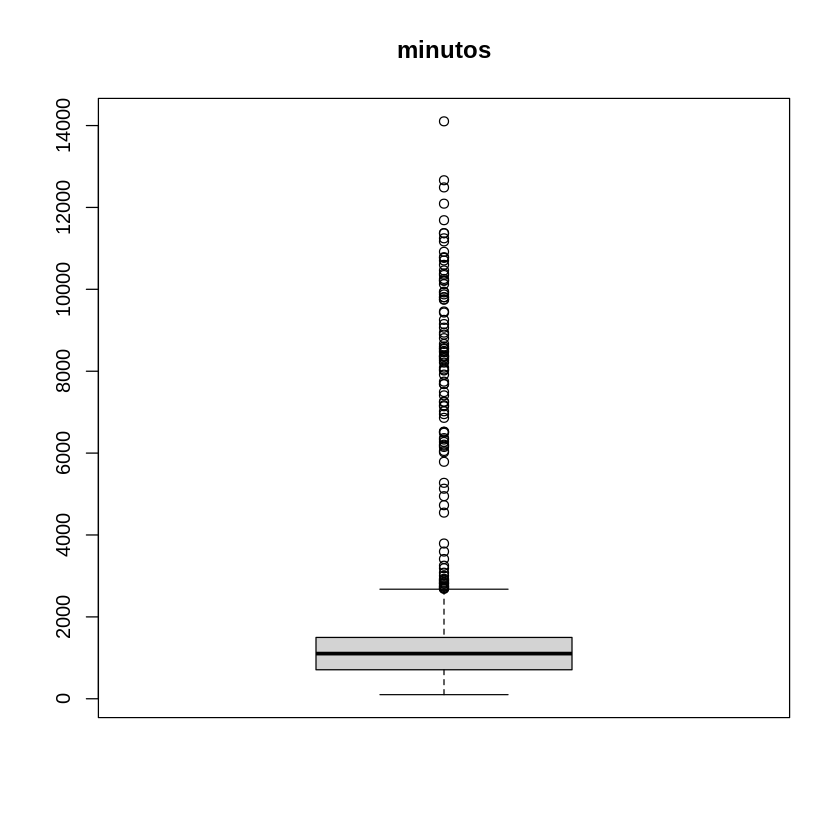

In [ ]:
#Aca revisamos como se comportan las variables numericas dentro del dataset
telco_fin<-telco
boxplot(telco_fin$`Antigüedad Equipo`, main = "Antiguedad")
boxplot(telco_fin$`facturación`,main = "Facturacion")
boxplot(telco_fin$mora, main = "mora")
boxplot(telco_fin$minutos, main = "minutos")


In [ ]:
telco_fin <- telco_fin %>%
  rename(
    tipo_cliente = `tipo cliente`,
    Factura_online = `Factura online`,
    Plan_de_datos = `Plan de datos`,
    facturacion = facturación,
    antiguedad_equipo = `Antigüedad Equipo`
  )

In [ ]:
#Dividimos el Dataset en entrenamiento y prueba
##entrenamiento y validación 80-20
set.seed(1)
sample <- sample.int(nrow(telco_fin), floor(.80*nrow(telco_fin)))
resultado.train <- telco_fin[sample, ]
resultado.test <- telco_fin[-sample, ]
#la clase esta desbalanceada, por tanto, la regresión logistica no se presenta como una solución al problema
table(resultado.train$resultado)


   0    1 
5511 1083 

#Modeling

Boosting

In [ ]:
#Aqui almaceno la variable objetivo para trabajar los pesos que asigne
y <- (resultado.train$resultado)
w <- ifelse(y == 1, 4, 1)

In [ ]:
boost_model <- gbm(resultado ~ ., data = resultado.train, distribution = "bernoulli", n.trees = 100, interaction.depth = 5,weights = w)

Random Forest

In [ ]:
set.seed(1)
# Entreno el modelo en el conjunto de entrenamiento
bag_model <- randomForest(resultado ~ ., data = resultado.train, mtry = 3, importance = TRUE, weights = w)

Warning message in randomForest.default(m, y, ...):
“The response has five or fewer unique values.  Are you sure you want to do regression?”


Validación Cruzada Boosting

In [ ]:
# Configuración de los hiperparametros para la validacion cruzada
tune_grid <- expand.grid(
  interaction.depth = seq(1, 5, by = 1),
  n.trees = c(50, 100, 150),               # Número de árboles
  shrinkage = c(0.01, 0.1),                # Tasa de aprendizaje
  n.minobsinnode = 10                      # Número mínimo de observaciones en cada nodo
)

In [ ]:
control <- trainControl(method = "cv", number = 5)

In [ ]:
set.seed(1)
gbm_model <- train(
  resultado ~ .,
  data = resultado.train,
  method = "gbm",
  trControl = control,
  tuneGrid = tune_grid,             # Cuadrícula de hiperparámetros
  verbose = FALSE
)

Warning message in train.default(x, y, weights = w, ...):
“You are trying to do regression and your outcome only has two possible values Are you trying to do classification? If so, use a 2 level factor as your outcome column.”


In [ ]:
# Mejores hiperparámetros
print(gbm_model$bestTune)

   n.trees interaction.depth shrinkage n.minobsinnode
26     100                 4       0.1             10


In [ ]:
#Creamos el mejor modelo con los hiperparametros de la validación cruzada boosting
set.seed(1)
boost_model2 <- gbm(resultado ~ ., data = resultado.train, distribution = "bernoulli", n.trees = 150, interaction.depth = 4,shrinkage = 0.1,n.minobsinnode = 10,weights = w)

Stacking

In [ ]:
h2o.init()

resultado_train_h2o <- as.h2o(resultado.train)
resultado_test_h2o <- as.h2o(resultado.test)

# Definir la variable objetivo y las predictoras
y <- "resultado"
x <- setdiff(names(resultado_train_h2o), y)

 Connection successful!

R is connected to the H2O cluster: 
    H2O cluster uptime:         17 minutes 33 seconds 
    H2O cluster timezone:       Etc/UTC 
    H2O data parsing timezone:  UTC 
    H2O cluster version:        3.44.0.3 
    H2O cluster version age:    10 months and 22 days 
    H2O cluster name:           H2O_started_from_R_root_ltp585 
    H2O cluster total nodes:    1 
    H2O cluster total memory:   3.13 GB 
    H2O cluster total cores:    2 
    H2O cluster allowed cores:  2 
    H2O cluster healthy:        TRUE 
    H2O Connection ip:          localhost 
    H2O Connection port:        54321 
    H2O Connection proxy:       NA 
    H2O Internal Security:      FALSE 
    R Version:                  R version 4.4.2 (2024-10-31) 


Warning message in h2o.clusterInfo():
“
Your H2O cluster version is (10 months and 22 days) old. There may be a newer version available.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html”



  |======================================================================| 100%
  |======================================================================| 100%


In [ ]:
# For binary classification, response should be a factor
resultado_train_h2o[, y] <- as.factor(resultado_train_h2o[, y])
resultado_test_h2o[, y] <- as.factor(resultado_test_h2o[, y])

In [ ]:
# Entrenar un modelo base GBM
#Para este caso usamos los hiperparametros que nos dieron mejor resultado con ayuda de la validación cruzada
my_gbm <- h2o.gbm(
  x = x,
  y = y,
  training_frame = resultado_train_h2o,
  ntrees = 150,                 # Número de árboles
  max_depth = 3,                # Profundidad de interacción
  learn_rate = 0.1,             # Tasa de aprendizaje (shrinkage)
  min_rows = 10,                # Número mínimo de observaciones en un nodo (n.minobsinnode)
  seed = 1,                     # Semilla para reproducibilidad
  keep_cross_validation_predictions = TRUE,  # Guardar predicciones de validación cruzada para el stacking
  nfolds = 5                    # Número de pliegues de validación cruzada
)

  |======================================================================| 100%


In [ ]:
# Train & Cross-validate a RF
my_rf <- h2o.randomForest(x = x,
                          y = y,
                          training_frame = resultado_train_h2o,
                          ntrees = 150,
                          nfolds = 2,
                          keep_cross_validation_predictions = TRUE,
                          seed = 1)

  |======================================================================| 100%


In [ ]:
# Train a stacked ensemble using the GBM and RF above
ensemble <- h2o.stackedEnsemble(x = x,
                                y = y,
                                training_frame = resultado_train_h2o,
                                base_models = list(my_gbm, my_rf))



  |======================================================================| 100%


#Evaluación

Random Forest

In [ ]:
prob_predictions <- predict(bag_model, newdata = resultado.test, type = "response")
predictions <- ifelse(prob_predictions > 0.5, 1, 0)
confusion <- confusionMatrix(as.factor(predictions), as.factor(resultado.test$resultado), positive = "1")
print(confusion)
confusion$byClass

Confusion Matrix and Statistics

          Reference
Prediction    0    1
         0 1259  145
         1  112  133
                                          
               Accuracy : 0.8441          
                 95% CI : (0.8257, 0.8613)
    No Information Rate : 0.8314          
    P-Value [Acc > NIR] : 0.08776         
                                          
                  Kappa : 0.4164          
                                          
 Mcnemar's Test P-Value : 0.04592         
                                          
            Sensitivity : 0.47842         
            Specificity : 0.91831         
         Pos Pred Value : 0.54286         
         Neg Pred Value : 0.89672         
             Prevalence : 0.16859         
         Detection Rate : 0.08065         
   Detection Prevalence : 0.14857         
      Balanced Accuracy : 0.69836         
                                          
       'Positive' Class : 1               
                        

Sensitivity          Specificity       Pos Pred Value 
          0.47841727           0.91830780           0.54285714 
      Neg Pred Value            Precision               Recall 
          0.89672365           0.54285714           0.47841727 
                  F1           Prevalence       Detection Rate 
          0.50860421           0.16858702           0.08065494 
Detection Prevalence    Balanced Accuracy 
          0.14857489           0.69836254

[1] 0.8297651

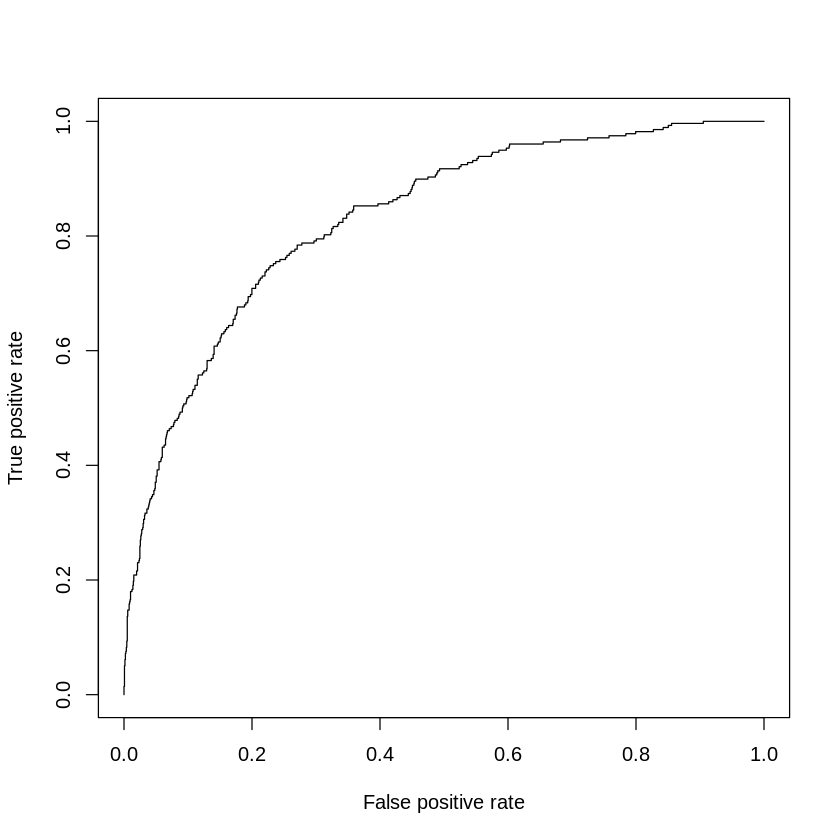

In [ ]:
pr<-prediction(prob_predictions,resultado.test$resultado)
curvaROC<-performance(pr,measure="tpr",x.measure="fpr")
plot(curvaROC)
auc<-performance(pr,measure = "auc")
auc <- auc@y.values[[1]]
#ver el AUC
auc

Boosting

In [ ]:
prob_predictions <- predict(boost_model, newdata = resultado.test, type = "response")
predictions <- ifelse(prob_predictions > 0.5, 1, 0)
confusion <- confusionMatrix(as.factor(predictions), as.factor(resultado.test$resultado), positive = "1")
print(confusion)
confusion$byClass

Using 100 trees...




Confusion Matrix and Statistics

          Reference
Prediction    0    1
         0 1167  100
         1  204  178
                                          
               Accuracy : 0.8156          
                 95% CI : (0.7961, 0.8341)
    No Information Rate : 0.8314          
    P-Value [Acc > NIR] : 0.9581          
                                          
                  Kappa : 0.4277          
                                          
 Mcnemar's Test P-Value : 3.474e-09       
                                          
            Sensitivity : 0.6403          
            Specificity : 0.8512          
         Pos Pred Value : 0.4660          
         Neg Pred Value : 0.9211          
             Prevalence : 0.1686          
         Detection Rate : 0.1079          
   Detection Prevalence : 0.2317          
      Balanced Accuracy : 0.7457          
                                          
       'Positive' Class : 1               
                        

Sensitivity          Specificity       Pos Pred Value 
           0.6402878            0.8512035            0.4659686 
      Neg Pred Value            Precision               Recall 
           0.9210734            0.4659686            0.6402878 
                  F1           Prevalence       Detection Rate 
           0.5393939            0.1685870            0.1079442 
Detection Prevalence    Balanced Accuracy 
           0.2316555            0.7457456

[1] 0.8478976

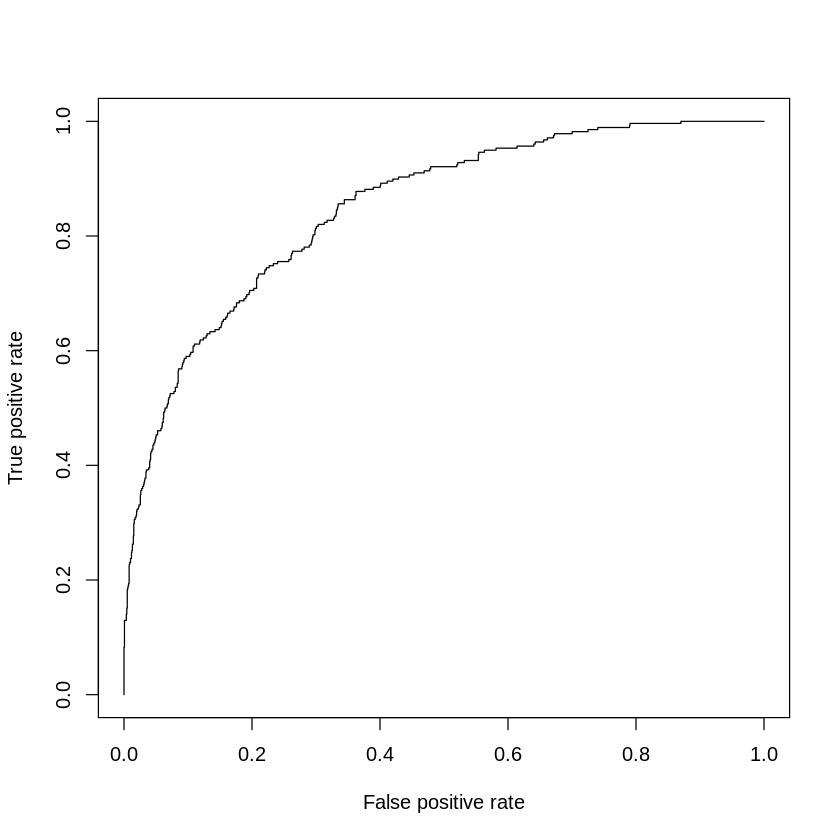

In [ ]:
pr<-prediction(prob_predictions,resultado.test$resultado)
curvaROC<-performance(pr,measure="tpr",x.measure="fpr")
plot(curvaROC)
auc<-performance(pr,measure = "auc")
auc <- auc@y.values[[1]]
auc

Validación Cruzada boosting

In [ ]:
prob_predictions <- predict(boost_model2, newdata = resultado.test, type = "response")
predictions <- ifelse(prob_predictions > 0.5, 1, 0)
confusion <- confusionMatrix(as.factor(predictions), as.factor(resultado.test$resultado), positive = "1")
print(confusion)
confusion$byClass

Using 150 trees...




Confusion Matrix and Statistics

          Reference
Prediction    0    1
         0 1170   93
         1  201  185
                                          
               Accuracy : 0.8217          
                 95% CI : (0.8024, 0.8399)
    No Information Rate : 0.8314          
    P-Value [Acc > NIR] : 0.8608          
                                          
                  Kappa : 0.4493          
                                          
 Mcnemar's Test P-Value : 4.365e-10       
                                          
            Sensitivity : 0.6655          
            Specificity : 0.8534          
         Pos Pred Value : 0.4793          
         Neg Pred Value : 0.9264          
             Prevalence : 0.1686          
         Detection Rate : 0.1122          
   Detection Prevalence : 0.2341          
      Balanced Accuracy : 0.7594          
                                          
       'Positive' Class : 1               
                        

Sensitivity          Specificity       Pos Pred Value 
           0.6654676            0.8533917            0.4792746 
      Neg Pred Value            Precision               Recall 
           0.9263658            0.4792746            0.6654676 
                  F1           Prevalence       Detection Rate 
           0.5572289            0.1685870            0.1121892 
Detection Prevalence    Balanced Accuracy 
           0.2340813            0.7594297

[1] 0.8539584

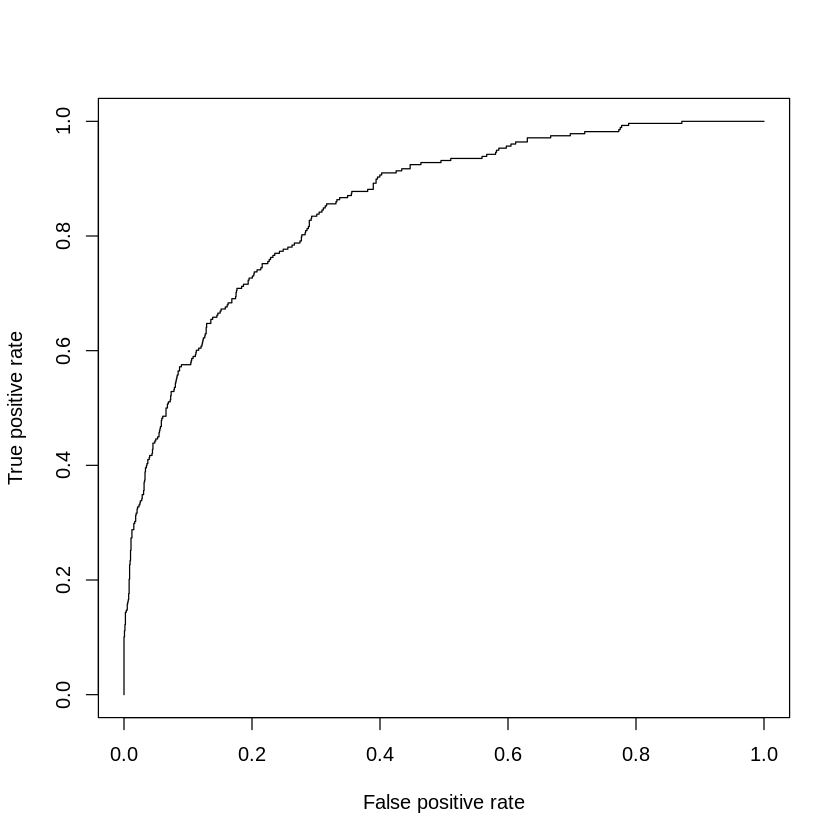

In [ ]:
#crear objeto de predicciones
pr<-prediction(prob_predictions,resultado.test$resultado)
#creacion del objeto de la curva
curvaROC<-performance(pr,measure="tpr",x.measure="fpr")
#grafico de la curva
plot(curvaROC)
#calcular el AUC
auc<-performance(pr,measure = "auc")
auc <- auc@y.values[[1]]
#ver el AUC
auc

Stacking

In [ ]:
# Eval ensemble performance on a test set
perf <- h2o.performance(ensemble, newdata = resultado_test_h2o)

In [ ]:
# Compare to base learner performance on the test set
perf_gbm_test <- h2o.performance(my_gbm, newdata = resultado_test_h2o)
perf_rf_test <- h2o.performance(my_rf, newdata = resultado_test_h2o)

print(sprintf("GBM Test AUC:  %s", h2o.auc(perf_gbm_test)))
print(sprintf("RF Test AUC:  %s", h2o.auc(perf_rf_test)))
print(sprintf("Ensemble Test AUC:  %s", h2o.auc(perf)))

[1] "GBM Test AUC:  0.850424255781371"
[1] "RF Test AUC:  0.822064449097177"
[1] "Ensemble Test AUC:  0.851111670838384"
